# Positional Encoding Implementation (Pure Python / NumPy)

This notebook implements the **Positional Encoding** mechanism from the seminal Transformer architecture paper, *"Attention Is All You Need"*.

Since Transformers do not use recurrent loops or convolutions, they lack an inherent sense of token order. Positional encoding adds a unique deterministic mathematical signal to each word token's embedding vector so the model can learn its position relative to the rest of the sequence.

### The Formulas
For a given position $pos$ and dimension index $i$:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$

### 1. Import Required Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Define the Positional Encoding Function

In [3]:
def get_positional_encoding(max_len: int, d_model: int) -> np.ndarray:
    """
    Generates a positional encoding matrix using NumPy.
    
    Args:
        max_len: Maximum length of the input sequences (sequence length).
        d_model: Dimension of the word embeddings (must be an even number).
        
    Returns:
        A numpy array of shape (max_len, d_model)
    """
    # Initialize the matrix with zeros
    pe = np.zeros((max_len, d_model))
    
    # Create an array of positions (0 to max_len - 1) and reshape to (max_len, 1)
    position = np.arange(0, max_len, dtype=np.float32)[:, np.newaxis]
    
    # Calculate the division term (the denominator in the geometric progression)
    # 2i represents even indices, so we step by 2
    div_term = np.exp(np.arange(0, d_model, 2, dtype=np.float32) * (-np.log(10000.0) / d_model))
    
    # Apply sine to even indices (0, 2, 4...)
    pe[:, 0::2] = np.sin(position * div_term)
    
    # Apply cosine to odd indices (1, 3, 5...)
    pe[:, 1::2] = np.cos(position * div_term)
    
    return pe

### 3. Example Usage & Shape Verification

In [4]:
# Define sequence parameters
seq_len = 10      # Number of word tokens in our dummy sentence
d_model = 16      # Size of each embedding vector

# Simulating a token embedding input batch (batch_size=2, seq_len=10, d_model=16)
np.random.seed(42)
token_embeddings = np.random.randn(2, seq_len, d_model)
print(f"Original Embeddings Shape: {token_embeddings.shape}")

# Generate positional encodings
pos_encoding = get_positional_encoding(max_len=seq_len, d_model=d_model)
print(f"Positional Encoding Shape: {pos_encoding.shape}")

# Add the encodings to the token embeddings (NumPy automatically broadcasts across the batch dimension)
encoded_embeddings = token_embeddings + pos_encoding
print(f"Encoded Embeddings Shape:  {encoded_embeddings.shape}")

Original Embeddings Shape: (2, 10, 16)
Positional Encoding Shape: (10, 16)
Encoded Embeddings Shape:  (2, 10, 16)


### 4. Visualizing the Encodings
To better understand the sin/cos patterns across various dimensions, let's plot a larger positional encoding matrix.

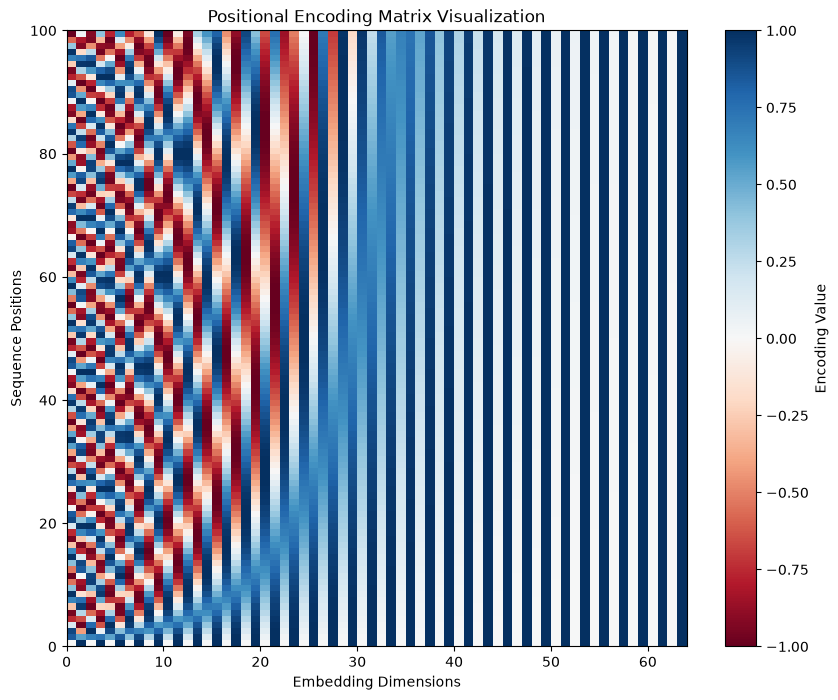

In [5]:
# Generate a larger matrix for visualization
vis_pe = get_positional_encoding(max_len=100, d_model=64)

plt.figure(figsize=(10, 8))
plt.pcolormesh(vis_pe, cmap='RdBu')
plt.xlabel('Embedding Dimensions')
plt.ylabel('Sequence Positions')
plt.colorbar(label='Encoding Value')
plt.title('Positional Encoding Matrix Visualization')
plt.show()